In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import shap
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score

# Data

In [2]:
df = pd.read_pickle('df.pkl')
df

,id,stem,a,b,c,d,correct_answer,incorrect_rate,signal_reasoning,signal_extra_triple,signal_distractor_depth,signal_node_embedding_similarity,signal_text_embedding_similarity,signal_degree_centrality,signal_readability,signal_above_largest_gap_count,signal_llm_extra_fact
0,1,"Born in the German Empire, which theoretical p...",Albert Einstein,Elon Reeve Musk,Lionel Andrés Messi,Eva Braun,A,0.131579,0.0,1.0,0.416667,0.548333,0.322126,0.660379,0.229622,0.0,0
1,2,Renowned for developing the Theory of Relativi...,Dennis Wilson,Stephen William Hawking,Albert Einstein,Karim Benzema,C,0.184211,0.0,0.0,0.250000,0.503333,0.260010,0.767297,0.229622,0.0,1
2,3,"A renowned physicist, who played a significant...",Thomas Jefferson,Nicki Minaj,Albert Einstein,Hillary Clinton,C,0.090909,1.0,1.0,0.250000,0.530000,0.216960,0.528304,0.356575,0.0,1
3,4,"What influential physicist, known for proposin...",Albert Einstein,Chuck Norris,Prince Philip,Richard Nixon,A,0.121212,1.0,0.0,0.333333,0.526667,0.277342,0.589625,0.268905,0.0,1
4,5,Who is the acclaimed actor and director known ...,Neil Patrick Harris,Rob Greenberg,Angelina Jolie,Donald Trump,C,0.243243,0.0,1.0,0.000000,0.545000,0.529586,0.613209,0.558968,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,"In 1914, the United Kingdom declared war on a ...",Sino-Soviet Split,Indochina Wars,Reactor Core Fire,World War I,D,0.189189,1.0,0.0,0.250000,0.523333,0.233798,0.490568,0.732613,0.0,0
152,153,By what name is the artist born as Kanye Omari...,Ye,Tim Burton,Kareem Abdul-Jabbar,Colonel Tom Parker,A,0.239130,0.0,1.0,0.250000,0.473333,0.713996,0.556606,0.821802,0.5,1
153,154,"Which individual, known for creating the album...",Scarlett Ingrid Johansson,Tony Bennett,Lionel Messi,Ye,D,0.545455,0.0,0.0,0.416667,0.486667,0.920057,0.691825,0.492456,1.0,1
154,155,"Which renowned musician, like Elvis Aaron Pres...",Sam Phillips,Kid Cudi,Ye,Bill Black,C,0.551724,1.0,1.0,0.666667,0.665000,1.000000,0.503147,0.438086,0.5,0


In [3]:
features = [
    "signal_reasoning",
    "signal_extra_triple",
    "signal_degree_centrality",
    "signal_distractor_depth",
    "signal_node_embedding_similarity",
    "signal_text_embedding_similarity",
    "signal_llm_extra_fact",
    "signal_readability",
    "signal_above_largest_gap_count",
]
target = "incorrect_rate"
X, y = df[features], df[target]
seed = 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Models

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.17
Mean Squared Error (MSE): 0.03
Mean Absolute Error (MAE): 0.13
R-squared (R2): 0.41
Correlation between y_pred and y_test (Pearson correlation - r): 0.70
                            Feature  Coefficient
0                  signal_reasoning    -0.042610
1               signal_extra_triple    -0.043119
2          signal_degree_centrality    -0.134771
3           signal_distractor_depth    -0.029610
4  signal_node_embedding_similarity     0.013565
5  signal_text_embedding_similarity     0.391318
6             signal_llm_extra_fact    -0.049385
7                signal_readability    -0.002274
8    signal_above_largest_gap_count     0.008426
Spearman's Rank Correlation Coefficient: 65.2%


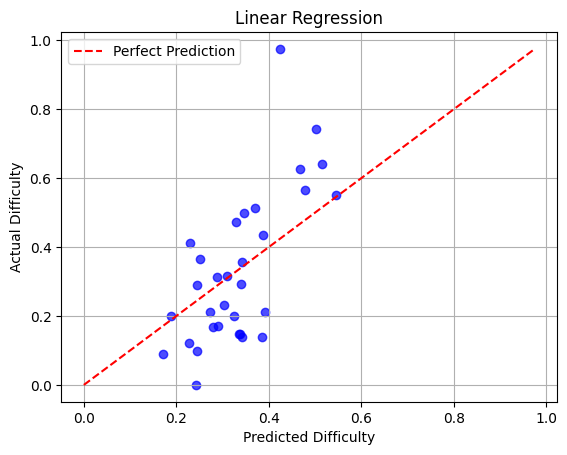

In [4]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Coefficients
coefficients = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
print(coefficients)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color="blue")
plt.title("Linear Regression")
plt.xlabel("Predicted Difficulty")
plt.ylabel("Actual Difficulty")
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
plt.legend()
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.17
Mean Squared Error (MSE): 0.03
Mean Absolute Error (MAE): 0.13
R-squared (R2): 0.42
Correlation between y_pred and y_test (Pearson correlation - r): 0.68
Spearman's Rank Correlation Coefficient: 67.1%


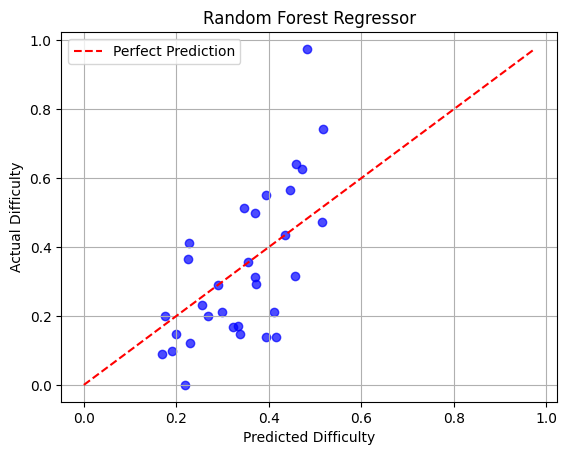

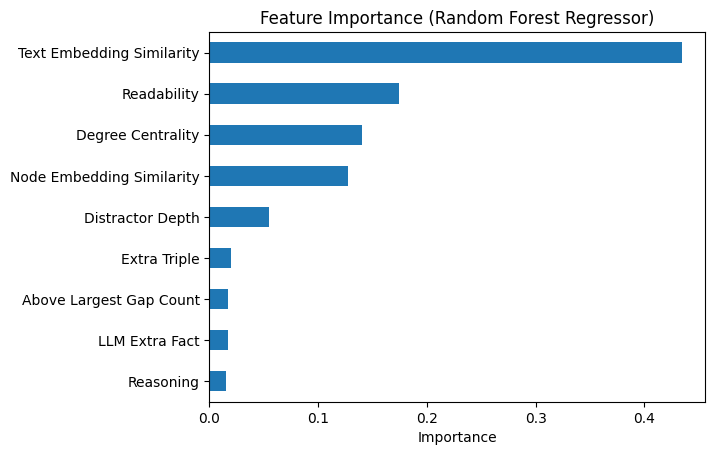

In [5]:
# RandomForestRegressor
model = RandomForestRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title("Random Forest Regressor")
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title(f'Feature Importance (Random Forest Regressor)')
plt.xlabel('Importance')
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.18
Mean Squared Error (MSE): 0.03
Mean Absolute Error (MAE): 0.14
R-squared (R2): 0.34
Correlation between y_pred and y_test (Pearson correlation - r): 0.59
Spearman's Rank Correlation Coefficient: 51.1%


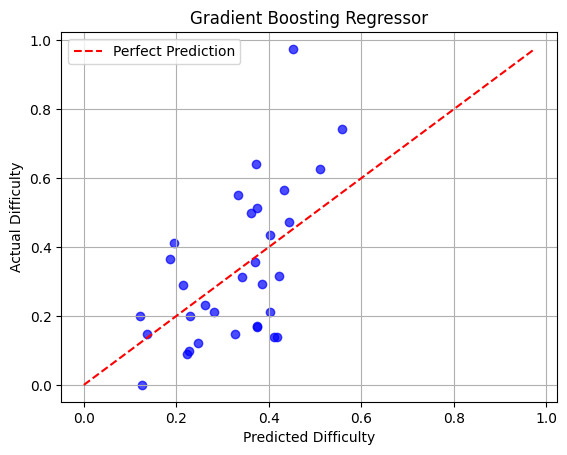

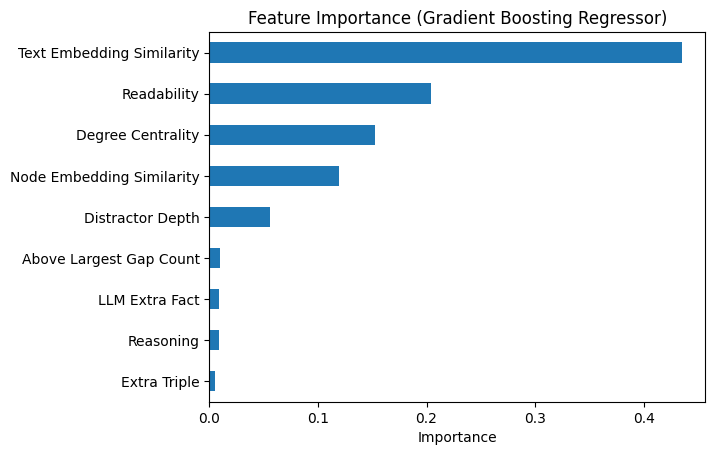

In [6]:
# GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title("Gradient Boosting Regressor")
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title(f'Feature Importance (Gradient Boosting Regressor)')
plt.xlabel('Importance')
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.57
Correlation between y_pred and y_test (Pearson correlation - r): 0.77
Spearman's Rank Correlation Coefficient: 67.5%


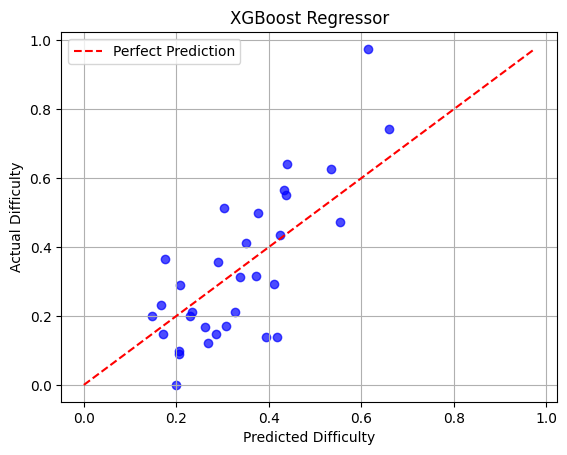

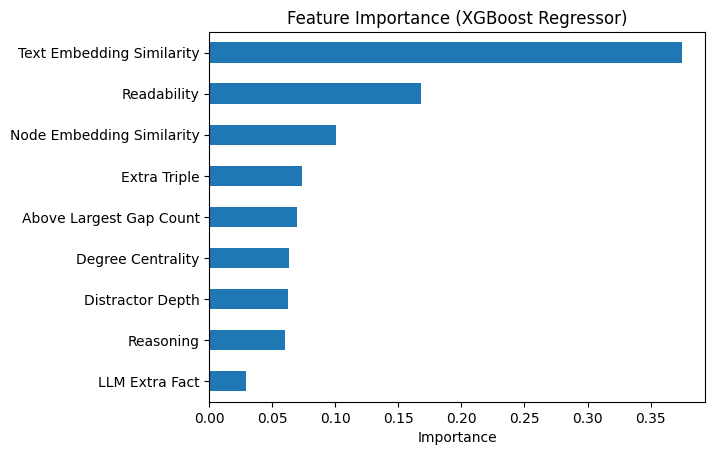

In [7]:
# XGBRegressor
model = XGBRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title('XGBoost Regressor')
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (XGBoost Regressor)')
plt.xlabel('Importance')
plt.show()

---

### What if we remove the outlier of the dataset?

In [8]:
outlier_idx = int(y_test[y_test == 0.975].index[0])
X_test = X_test.drop(outlier_idx)
y_test = y_test.drop(outlier_idx)

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.46
Correlation between y_pred and y_test (Pearson correlation - r): 0.72
                            Feature  Coefficient
0                  signal_reasoning    -0.042610
1               signal_extra_triple    -0.043119
2          signal_degree_centrality    -0.134771
3           signal_distractor_depth    -0.029610
4  signal_node_embedding_similarity     0.013565
5  signal_text_embedding_similarity     0.391318
6             signal_llm_extra_fact    -0.049385
7                signal_readability    -0.002274
8    signal_above_largest_gap_count     0.008426
Spearman's Rank Correlation Coefficient: 62.4%


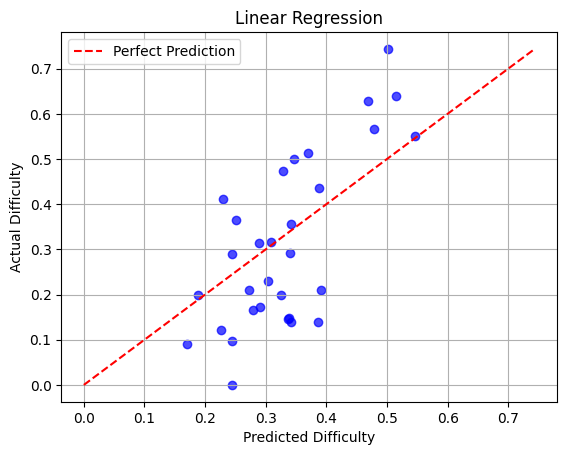

In [9]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Coefficients
coefficients = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
print(coefficients)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color="blue")
plt.title("Linear Regression")
plt.xlabel("Predicted Difficulty")
plt.ylabel("Actual Difficulty")
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
plt.legend()
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.41
Correlation between y_pred and y_test (Pearson correlation - r): 0.67
Spearman's Rank Correlation Coefficient: 64.2%


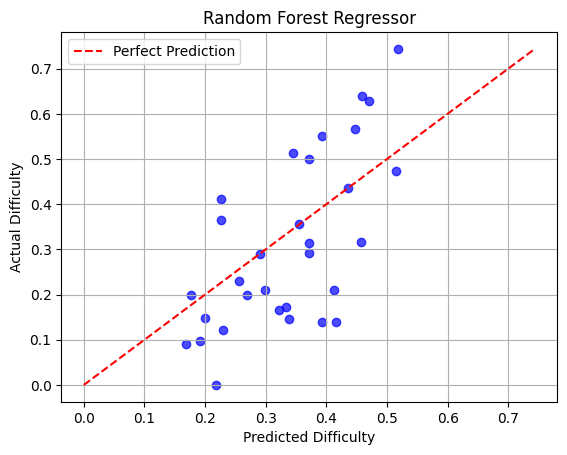

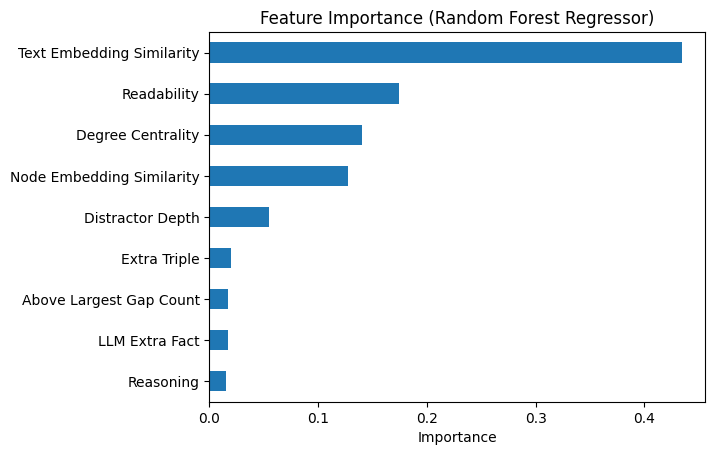

In [10]:
# RandomForestRegressor
model = RandomForestRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title("Random Forest Regressor")
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title(f'Feature Importance (Random Forest Regressor)')
plt.xlabel('Importance')
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.15
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.13
R-squared (R2): 0.34
Correlation between y_pred and y_test (Pearson correlation - r): 0.59
Spearman's Rank Correlation Coefficient: 46.4%


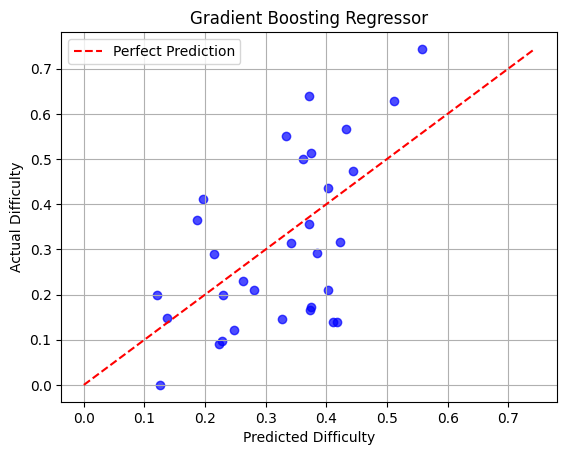

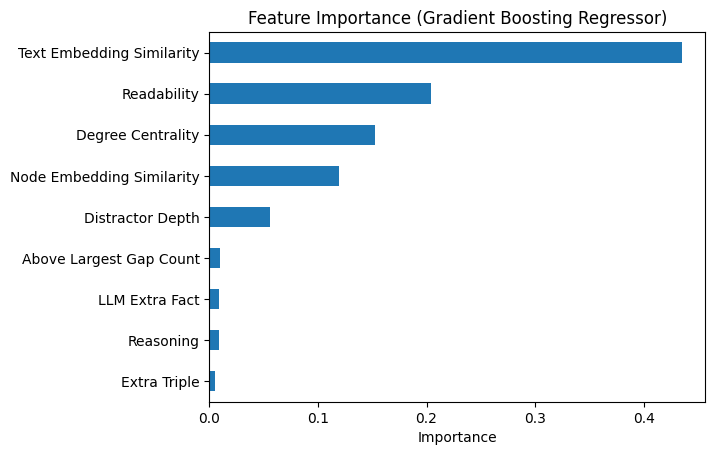

In [11]:
# GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title("Gradient Boosting Regressor")
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title(f'Feature Importance (Gradient Boosting Regressor)')
plt.xlabel('Importance')
plt.show()

Target: incorrect_rate
Root Mean Squared Error (RMSE): 0.13
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.52
Correlation between y_pred and y_test (Pearson correlation - r): 0.73
Spearman's Rank Correlation Coefficient: 64.3%


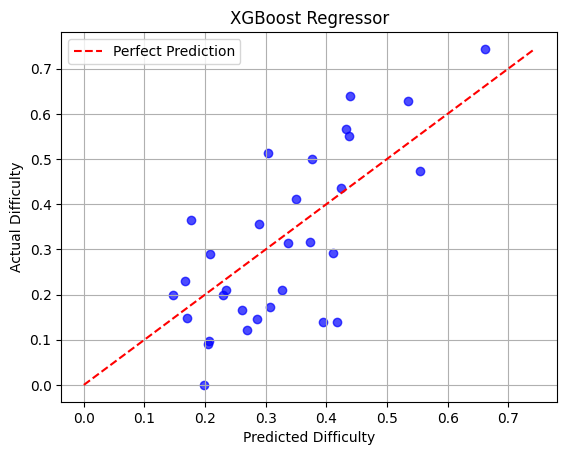

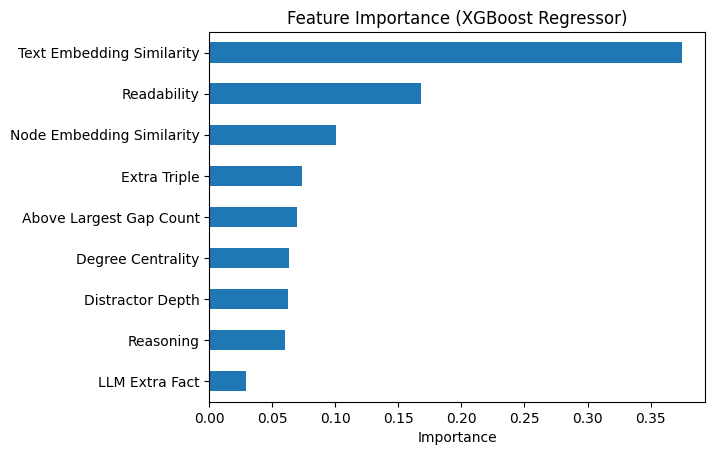

In [12]:
# XGBRegressor
model = XGBRegressor(random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Target: {target}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(
    f"Correlation between y_pred and y_test (Pearson correlation - r): {np.corrcoef(y_pred, y_test)[0, 1]:.2f}"
)

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
# Calculate Spearman's Rank Correlation Coefficient
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title('XGBoost Regressor')
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

custom_feature_names = [
    'Reasoning',
    'Extra Triple',
    'Degree Centrality',
    'Distractor Depth',
    'Node Embedding Similarity',
    'Text Embedding Similarity',
    'LLM Extra Fact',
    'Readability',
    'Above Largest Gap Count',
]
# Feature importance with custom names
feature_importance = pd.Series(model.feature_importances_, index=custom_feature_names)
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (XGBoost Regressor)')
plt.xlabel('Importance')
plt.show()

---

### SHAP for XGBoost Regressor

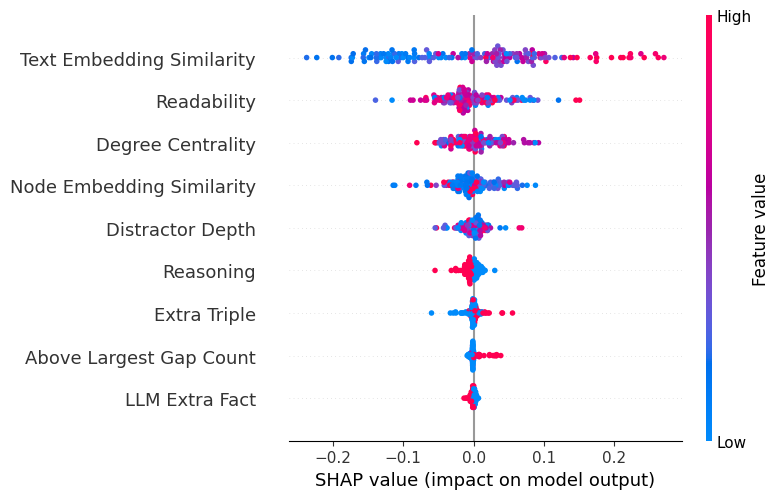

In [13]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X)
shap.summary_plot(explanation, X, feature_names=custom_feature_names)

---

### Ablation Study

Removing feature: signal_reasoning
Root Mean Squared Error (RMSE): 0.13
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.53
Correlation between y_pred and y_test (Pearson correlation - r): 0.73
Spearman's Rank Correlation Coefficient: 69.0%


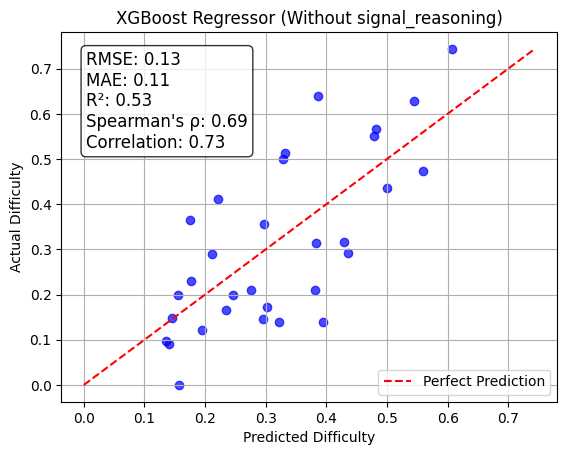

Removing feature: signal_extra_triple
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.47
Correlation between y_pred and y_test (Pearson correlation - r): 0.69
Spearman's Rank Correlation Coefficient: 61.3%


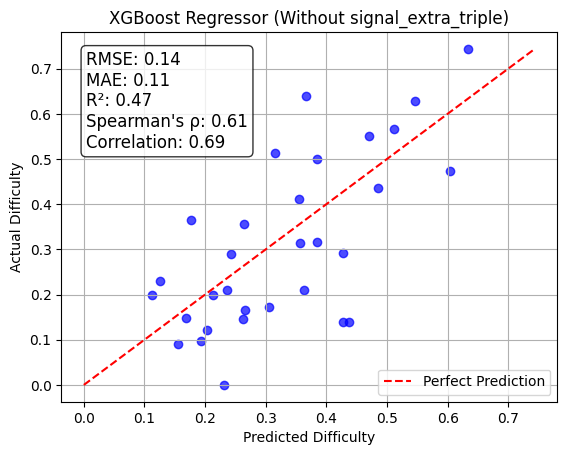

Removing feature: signal_degree_centrality
Root Mean Squared Error (RMSE): 0.13
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.50
Correlation between y_pred and y_test (Pearson correlation - r): 0.72
Spearman's Rank Correlation Coefficient: 65.4%


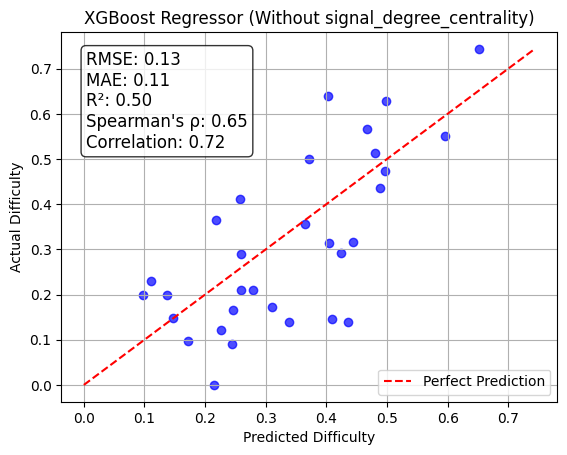

Removing feature: signal_distractor_depth
Root Mean Squared Error (RMSE): 0.15
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.13
R-squared (R2): 0.32
Correlation between y_pred and y_test (Pearson correlation - r): 0.57
Spearman's Rank Correlation Coefficient: 45.4%


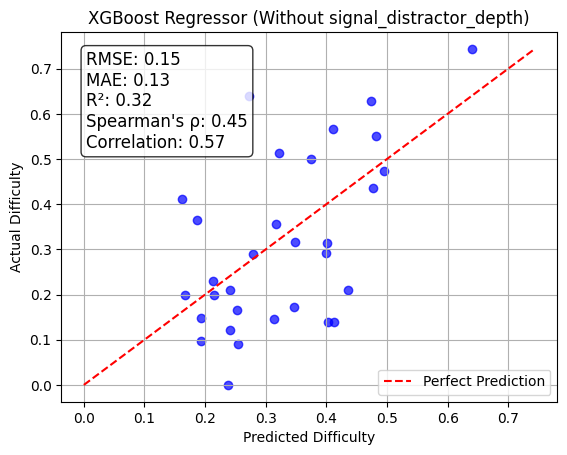

Removing feature: signal_node_embedding_similarity
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.42
Correlation between y_pred and y_test (Pearson correlation - r): 0.66
Spearman's Rank Correlation Coefficient: 59.0%


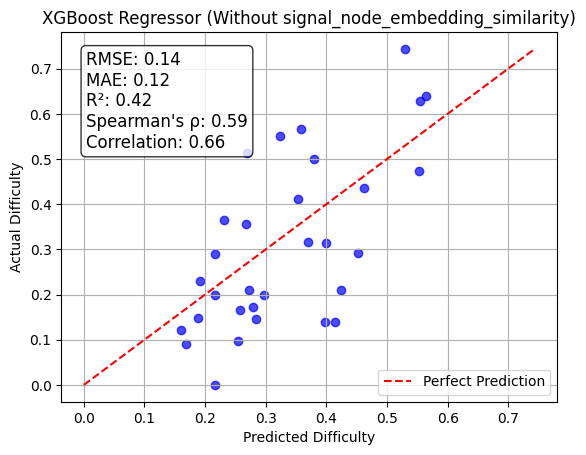

Removing feature: signal_text_embedding_similarity
Root Mean Squared Error (RMSE): 0.21
Mean Squared Error (MSE): 0.05
Mean Absolute Error (MAE): 0.18
R-squared (R2): -0.32
Correlation between y_pred and y_test (Pearson correlation - r): -0.03
Spearman's Rank Correlation Coefficient: -7.4%


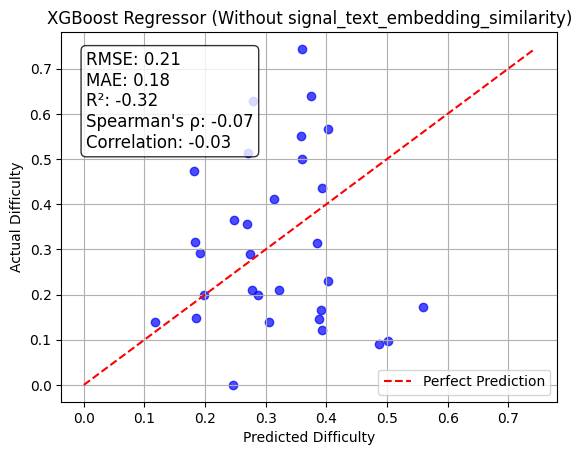

Removing feature: signal_llm_extra_fact
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.47
Correlation between y_pred and y_test (Pearson correlation - r): 0.70
Spearman's Rank Correlation Coefficient: 61.0%


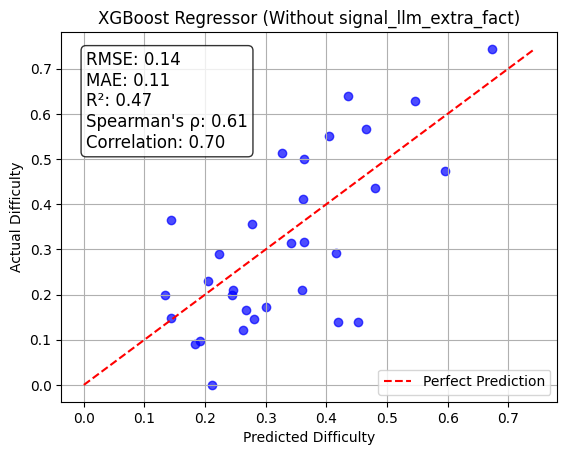

Removing feature: signal_readability
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.44
Correlation between y_pred and y_test (Pearson correlation - r): 0.66
Spearman's Rank Correlation Coefficient: 60.8%


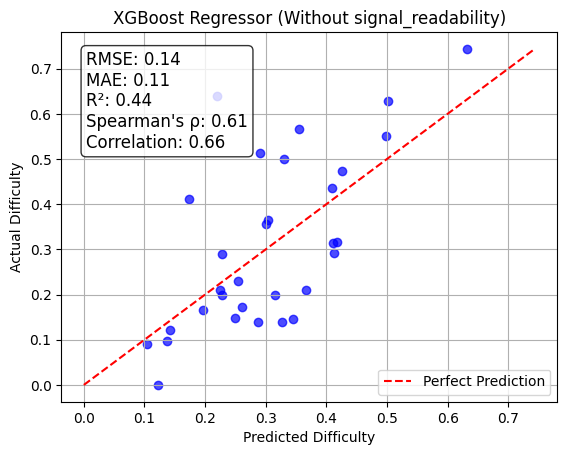

Removing feature: signal_above_largest_gap_count
Root Mean Squared Error (RMSE): 0.13
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.11
R-squared (R2): 0.50
Correlation between y_pred and y_test (Pearson correlation - r): 0.71
Spearman's Rank Correlation Coefficient: 59.7%


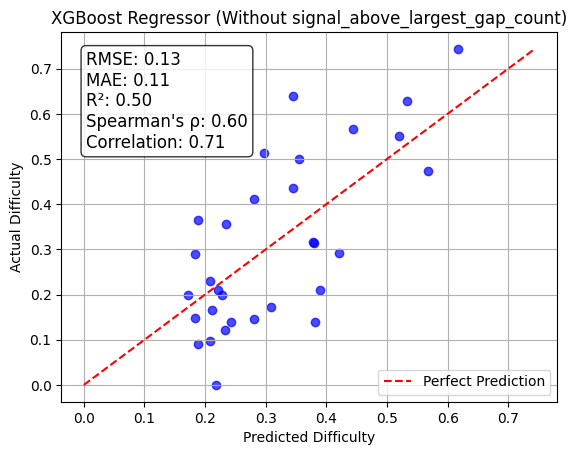

In [14]:
# Ablation study
for feature_to_remove in features:
    print(f"Removing feature: {feature_to_remove}")
    
    # Remove the feature
    X_train_ablation = X_train.drop(columns=[feature_to_remove])
    X_test_ablation = X_test.drop(columns=[feature_to_remove])
    
    # Retrain the model
    model = XGBRegressor(random_state=seed)
    model.fit(X_train_ablation, y_train)
    y_pred = model.predict(X_test_ablation)
    
    # Compute metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    pearson_corr = np.corrcoef(y_pred, y_test)[0, 1]
    
    # Rank the predictions and ground truth
    predicted_ranks = y_pred.argsort().argsort()
    ground_truth_ranks = y_test.argsort().argsort()
    spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
    
    # Print metrics
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
    print(f"Correlation between y_pred and y_test (Pearson correlation - r): {pearson_corr:.2f}")
    print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")
    
    # Plot
    plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
    plt.title(f"XGBoost Regressor (Without {feature_to_remove})")
    plt.xlabel('Predicted Difficulty')
    plt.ylabel('Actual Difficulty')
    plt.grid(True)
    
    # Add metrics in a text box
    metrics_text = (
        f"RMSE: {rmse:.2f}\n"
        f"MAE: {mae:.2f}\n"
        f"R²: {r2:.2f}\n"
        f"Spearman's ρ: {spearman_corr:.2f}\n"
        f"Correlation: {pearson_corr:.2f}"
    )
    plt.text(
        0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )
    
    min_val = min(y_pred.min(), y_test.min())
    max_val = max(y_pred.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
    plt.legend()
    plt.show()

Removing features: signal_reasoning and signal_degree_centrality
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.43
Correlation between y_pred and y_test (Pearson correlation - r): 0.69
Spearman's Rank Correlation Coefficient: 64.8%


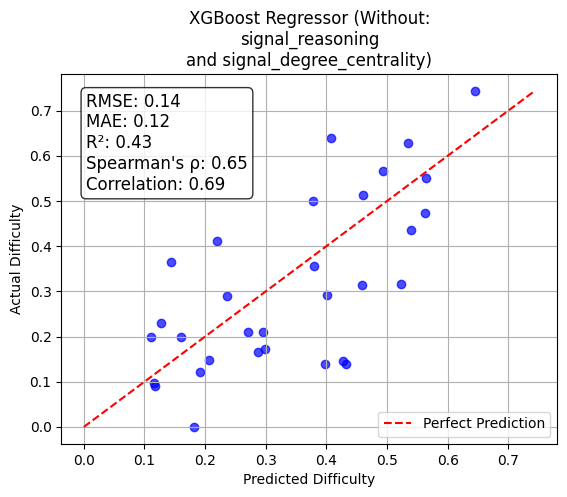

Removing features: signal_reasoning and signal_above_largest_gap_count
Root Mean Squared Error (RMSE): 0.12
Mean Squared Error (MSE): 0.01
Mean Absolute Error (MAE): 0.10
R-squared (R2): 0.58
Correlation between y_pred and y_test (Pearson correlation - r): 0.77
Spearman's Rank Correlation Coefficient: 66.1%


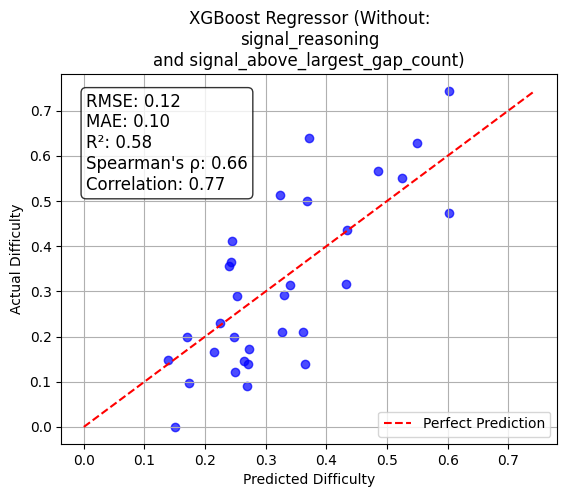

Removing features: signal_degree_centrality and signal_above_largest_gap_count
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.43
Correlation between y_pred and y_test (Pearson correlation - r): 0.68
Spearman's Rank Correlation Coefficient: 65.2%


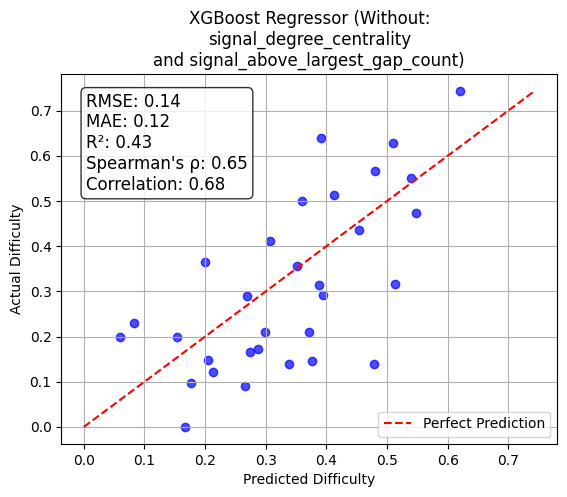

In [15]:
# Ablation study with two features removed
features_to_remove_pairs = [
    ("signal_reasoning", "signal_degree_centrality"),
    ("signal_reasoning", "signal_above_largest_gap_count"),
    ("signal_degree_centrality", "signal_above_largest_gap_count"),
]

for feature_pair in features_to_remove_pairs:
    print(f"Removing features: {feature_pair[0]} and {feature_pair[1]}")
    
    # Remove the features
    X_train_ablation = X_train.drop(columns=list(feature_pair))
    X_test_ablation = X_test.drop(columns=list(feature_pair))
    
    # Retrain the model
    model = XGBRegressor(random_state=seed)
    model.fit(X_train_ablation, y_train)
    y_pred = model.predict(X_test_ablation)
    
    # Compute metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    pearson_corr = np.corrcoef(y_pred, y_test)[0, 1]
    
    # Rank the predictions and ground truth
    predicted_ranks = y_pred.argsort().argsort()
    ground_truth_ranks = y_test.argsort().argsort()
    spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)
    
    # Print metrics
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
    print(f"Correlation between y_pred and y_test (Pearson correlation - r): {pearson_corr:.2f}")
    print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")
    
    # Plot
    plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
    plt.title("XGBoost Regressor (Without:\n" + feature_pair[0] + "\nand " + feature_pair[1] + ")")
    # plt.title(f"XGBoost Regressor (Without {feature_pair[0]} and {feature_pair[1]})")
    plt.xlabel('Predicted Difficulty')
    plt.ylabel('Actual Difficulty')
    plt.grid(True)
    
    # Add metrics in a text box
    metrics_text = (
        f"RMSE: {rmse:.2f}\n"
        f"MAE: {mae:.2f}\n"
        f"R²: {r2:.2f}\n"
        f"Spearman's ρ: {spearman_corr:.2f}\n"
        f"Correlation: {pearson_corr:.2f}"
    )
    plt.text(
        0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )
    
    min_val = min(y_pred.min(), y_test.min())
    max_val = max(y_pred.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
    plt.legend()
    plt.show()

Removing features: signal_reasoning, signal_degree_centrality, signal_above_largest_gap_count
Root Mean Squared Error (RMSE): 0.14
Mean Squared Error (MSE): 0.02
Mean Absolute Error (MAE): 0.12
R-squared (R2): 0.45
Correlation between y_pred and y_test (Pearson correlation - r): 0.68
Spearman's Rank Correlation Coefficient: 64.8%


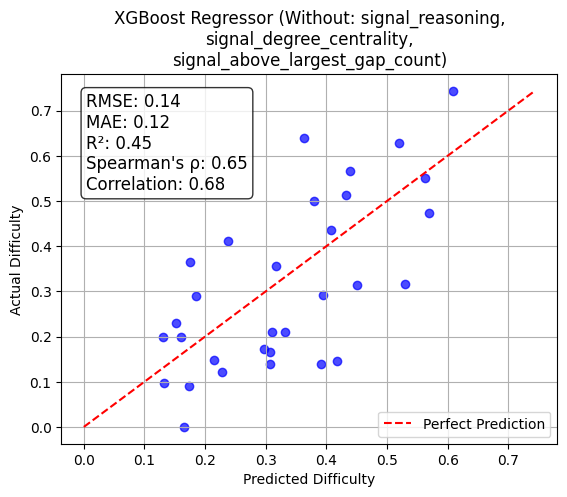

In [16]:
# Remove the three features for ablation study
features_to_remove = ["signal_reasoning", "signal_degree_centrality", "signal_above_largest_gap_count"]
print(f"Removing features: {', '.join(features_to_remove)}")

# Remove the features
X_train_ablation = X_train.drop(columns=features_to_remove)
X_test_ablation = X_test.drop(columns=features_to_remove)

# Retrain the model
model = XGBRegressor(random_state=seed)
model.fit(X_train_ablation, y_train)
y_pred = model.predict(X_test_ablation)

# Compute metrics
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
pearson_corr = np.corrcoef(y_pred, y_test)[0, 1]

# Rank the predictions and ground truth
predicted_ranks = y_pred.argsort().argsort()
ground_truth_ranks = y_test.argsort().argsort()
spearman_corr, _ = spearmanr(predicted_ranks, ground_truth_ranks)

# Print metrics
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(f"Correlation between y_pred and y_test (Pearson correlation - r): {pearson_corr:.2f}")
print(f"Spearman's Rank Correlation Coefficient: {spearman_corr * 100:.1f}%")

# Plot
plt.scatter(y_pred, y_test, alpha=0.7, color='blue')
plt.title("XGBoost Regressor (Without: " + ',\n'.join(features_to_remove) + ")")
plt.xlabel('Predicted Difficulty')
plt.ylabel('Actual Difficulty')
plt.grid(True)

# Add metrics in a text box
metrics_text = (
    f"RMSE: {rmse:.2f}\n"
    f"MAE: {mae:.2f}\n"
    f"R²: {r2:.2f}\n"
    f"Spearman's ρ: {spearman_corr:.2f}\n"
    f"Correlation: {pearson_corr:.2f}"
)
plt.text(
    0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()